# Notebook 04: Comparativa de Modelos y Optimización de Hiperparámetros

**Entrada:** `data/processed/dataset.csv`  
**Salida:** `models/best_model.pkl`

## Contexto: ¿Por qué F1 y AUC-ROC, NO Accuracy?

Este proyecto predice **antigenicidad de proteínas** para el diseño de vacunas.  
El dataset tiene un desbalance **7:1** (no antigénicas vs antigénicas).

| Métrica | Por qué importa en este contexto |
|---------|----------------------------------|
| **Accuracy** | ❌ Engañosa: un modelo que prediga siempre 'no antigénica' obtiene ~87% de accuracy sin aprender nada |
| **Recall (Sensibilidad)** | ✅ Crítico: un **falso negativo** (perder una proteína antigénica) es más costoso que un falso positivo |
| **Precision** | ✅ Importante: evitar candidatos inútiles que encarecen experimentos de laboratorio |
| **F1-score** | ✅ **Métrica principal**: equilibrio precision-recall, robusto ante desbalance |
| **AUC-ROC** | ✅ **Métrica de ranking**: evalúa qué tan bien el modelo separa las clases a cualquier umbral |

> **Regla de oro en diseño de vacunas**: priorizar **Recall alto** (no perder candidatos) y usar **F1** como compromiso. Si hay recursos limitados de laboratorio, subir el umbral para mejorar Precision.

## Estrategia de mejora
1. Split **70% train / 15% validation / 15% test** (hold-out final intocable)
2. Cross-validation estratificada k=5 sobre el **train+validation** para selección de modelo
3. Comparar **Random Forest, SVM y LightGBM** con hiperparámetros optimizados
4. Evaluación final honesta sobre el **test set** con el mejor modelo


## 0. Configuración

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import lightgbm as lgb

# Validación y búsqueda de hiperparámetros
from sklearn.model_selection import (
    StratifiedKFold, cross_validate,
    RandomizedSearchCV, train_test_split
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Métricas
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score,
    classification_report, RocCurveDisplay,
    ConfusionMatrixDisplay, PrecisionRecallDisplay
)

# Scipy para distribuciones de hiperparámetros
from scipy.stats import randint, uniform

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE  = 42
print("Librerías cargadas correctamente.")
print(f"LightGBM version: {lgb.__version__}")

Librerías cargadas correctamente.
LightGBM version: 4.6.0


## 1. Cargar datos y split 70 / 15 / 15

In [6]:
dataset = pd.read_csv(PROCESSED_DIR / 'dataset.csv')
print(f"Dataset cargado: {dataset.shape[0]:,} filas × {dataset.shape[1]} columnas")
print(f"Distribución de labels: {dataset['label'].value_counts().to_dict()}")

AMINO_ACIDS  = list('ACDEFGHIKLMNPQRSTVWY')
FEATURE_COLS = ['length', 'molecular_weight', 'isoelectric_point', 'gravy'] + \
               [f'aa_{aa}' for aa in AMINO_ACIDS]

X = dataset[FEATURE_COLS].values
y = dataset['label'].values

# ─── Step 1: separar test (15%) de forma estratificada ───────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE
)

# ─── Step 2: separar validation (15% del total = ~17.6% del trainval) ────────
val_frac = 0.15 / 0.85  # = 0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_frac,
    stratify=y_trainval,
    random_state=RANDOM_STATE
)

print(f"\n{'Conjunto':<15} {'Muestras':>10} {'Antigénicas':>15} {'Ratio':>10}")
print("-" * 55)
for name, yy in [('Train (70%)', y_train), ('Val (15%)', y_val), ('Test (15%)', y_test)]:
    n = len(yy)
    pos = yy.sum()
    print(f"{name:<15} {n:>10,} {pos:>15,} {pos/n:>10.1%}")

print(f"\nTotal: {len(y):,} proteínas | {X.shape[1]} features")

Dataset cargado: 1,310 filas × 29 columnas
Distribución de labels: {1: 1149, 0: 161}

Conjunto          Muestras     Antigénicas      Ratio
-------------------------------------------------------
Train (70%)            916             803      87.7%
Val (15%)              197             173      87.8%
Test (15%)             197             173      87.8%

Total: 1,310 proteínas | 24 features


## 2. Definir modelos base (sin optimizar) para referencia

In [7]:
# Cross-validation sobre trainval (70+15) para evaluación robusta
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

base_models = {
    'Random Forest (base)': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'SVM (base)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf',
            class_weight='balanced',
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]),
    'LightGBM (base)': lgb.LGBMClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
}

scoring = ['roc_auc', 'f1', 'recall', 'precision', 'accuracy']
base_results = {}

print("Evaluando modelos base con CV-5 sobre trainval...")
for name, model in base_models.items():
    print(f"  → {name}...")
    res = cross_validate(model, X_trainval, y_trainval, cv=cv, scoring=scoring, n_jobs=-1)
    base_results[name] = res
    print(f"     AUC={res['test_roc_auc'].mean():.3f}  F1={res['test_f1'].mean():.3f}  Recall={res['test_recall'].mean():.3f}")

print("\n✓ Evaluación base completada.")

Evaluando modelos base con CV-5 sobre trainval...
  → Random Forest (base)...
     AUC=0.699  F1=0.932  Recall=0.973
  → SVM (base)...
     AUC=0.621  F1=0.751  Recall=0.645
  → LightGBM (base)...
     AUC=0.691  F1=0.917  Recall=0.934

✓ Evaluación base completada.


## 3. Optimización de hiperparámetros con RandomizedSearchCV

> Se optimiza sobre **F1** como scoring principal (el más importante para este problema).

In [8]:
# ═══════════════════════════════════════════════════
#  3a. RANDOM FOREST — búsqueda de hiperparámetros
# ═══════════════════════════════════════════════════
rf_param_dist = {
    'n_estimators':      randint(100, 600),
    'max_depth':         [None, 5, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.3, 0.5],
    'class_weight':      ['balanced', 'balanced_subsample']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=40,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)
print("Optimizando Random Forest (40 iteraciones)...")
rf_search.fit(X_trainval, y_trainval)
print(f"  Mejor F1 CV: {rf_search.best_score_:.4f}")
print(f"  Mejores params: {rf_search.best_params_}")

Optimizando Random Forest (40 iteraciones)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
  Mejor F1 CV: 0.9307
  Mejores params: {'class_weight': 'balanced_subsample', 'max_depth': 30, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 502}


In [9]:
# ═══════════════════════════════════════════════════
#  3b. SVM — búsqueda de hiperparámetros
# ═══════════════════════════════════════════════════
svm_param_dist = {
    'clf__C':       uniform(0.01, 100),
    'clf__gamma':   ['scale', 'auto'] + list(uniform(0.001, 1).rvs(5, random_state=RANDOM_STATE)),
    'clf__kernel':  ['rbf', 'poly', 'sigmoid'],
    'clf__class_weight': ['balanced']
}

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(probability=True, random_state=RANDOM_STATE))
])

svm_search = RandomizedSearchCV(
    svm_pipeline,
    param_distributions=svm_param_dist,
    n_iter=25,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)
print("Optimizando SVM (25 iteraciones)...")
svm_search.fit(X_trainval, y_trainval)
print(f"  Mejor F1 CV: {svm_search.best_score_:.4f}")
print(f"  Mejores params: {svm_search.best_params_}")

Optimizando SVM (25 iteraciones)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
  Mejor F1 CV: 0.8860
  Mejores params: {'clf__C': np.float64(68.33635188254583), 'clf__class_weight': 'balanced', 'clf__gamma': np.float64(0.9517143064099162), 'clf__kernel': 'rbf'}


In [10]:
# ═══════════════════════════════════════════════════
#  3c. LightGBM — búsqueda de hiperparámetros
# ═══════════════════════════════════════════════════
lgb_param_dist = {
    'n_estimators':     randint(100, 800),
    'learning_rate':    uniform(0.01, 0.3),
    'num_leaves':       randint(20, 150),
    'max_depth':        randint(3, 15),
    'min_child_samples':randint(10, 100),
    'subsample':        uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha':        uniform(0, 1),
    'reg_lambda':       uniform(0, 1),
    'class_weight':     ['balanced']
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    param_distributions=lgb_param_dist,
    n_iter=40,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)
print("Optimizando LightGBM (40 iteraciones)...")
lgb_search.fit(X_trainval, y_trainval)
print(f"  Mejor F1 CV: {lgb_search.best_score_:.4f}")
print(f"  Mejores params: {lgb_search.best_params_}")

Optimizando LightGBM (40 iteraciones)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
  Mejor F1 CV: 0.9150
  Mejores params: {'class_weight': 'balanced', 'colsample_bytree': np.float64(0.5806106436270022), 'learning_rate': np.float64(0.2889092957027719), 'max_depth': 11, 'min_child_samples': 15, 'n_estimators': 127, 'num_leaves': 127, 'reg_alpha': np.float64(0.18657005888603584), 'reg_lambda': np.float64(0.8925589984899778), 'subsample': np.float64(0.7696711209578253)}


## 4. Comparativa completa: base vs. optimizado

In [11]:
optimized_models = {
    'Random Forest (opt)': rf_search.best_estimator_,
    'SVM (opt)':           svm_search.best_estimator_,
    'LightGBM (opt)':      lgb_search.best_estimator_,
}

opt_results = {}
print("Evaluando modelos optimizados con CV-5 sobre trainval...")
for name, model in optimized_models.items():
    print(f"  → {name}...")
    res = cross_validate(model, X_trainval, y_trainval, cv=cv, scoring=scoring, n_jobs=-1)
    opt_results[name] = res
    print(f"     AUC={res['test_roc_auc'].mean():.3f}  F1={res['test_f1'].mean():.3f}  Recall={res['test_recall'].mean():.3f}")

# ─── Tabla comparativa completa ──────────────────────────────────────────────
all_results = {**base_results, **opt_results}

rows = []
for name, res in all_results.items():
    rows.append({
        'Modelo':     name,
        'AUC-ROC':    f"{res['test_roc_auc'].mean():.3f} ± {res['test_roc_auc'].std():.3f}",
        'F1':         f"{res['test_f1'].mean():.3f} ± {res['test_f1'].std():.3f}",
        'Recall':     f"{res['test_recall'].mean():.3f} ± {res['test_recall'].std():.3f}",
        'Precision':  f"{res['test_precision'].mean():.3f} ± {res['test_precision'].std():.3f}",
        'Accuracy':   f"{res['test_accuracy'].mean():.3f} ± {res['test_accuracy'].std():.3f}",
    })

df_compare = pd.DataFrame(rows).set_index('Modelo')
print("\n=== Comparativa completa (CV-5, mean ± std) ===")
display(df_compare)

Evaluando modelos optimizados con CV-5 sobre trainval...
  → Random Forest (opt)...
     AUC=0.702  F1=0.931  Recall=0.970
  → SVM (opt)...
     AUC=0.657  F1=0.886  Recall=0.870
  → LightGBM (opt)...
     AUC=0.702  F1=0.915  Recall=0.928

=== Comparativa completa (CV-5, mean ± std) ===


,AUC-ROC,F1,Recall,Precision,Accuracy
Modelo,,,,,
Random Forest (base),0.699 ± 0.047,0.932 ± 0.007,0.973 ± 0.009,0.895 ± 0.009,0.876 ± 0.014
SVM (base),0.621 ± 0.039,0.751 ± 0.030,0.645 ± 0.045,0.901 ± 0.010,0.626 ± 0.034
LightGBM (base),0.691 ± 0.048,0.917 ± 0.011,0.934 ± 0.019,0.901 ± 0.010,0.853 ± 0.019
Random Forest (opt),0.702 ± 0.050,0.931 ± 0.006,0.970 ± 0.009,0.894 ± 0.006,0.873 ± 0.010
SVM (opt),0.657 ± 0.069,0.886 ± 0.017,0.870 ± 0.029,0.903 ± 0.006,0.804 ± 0.027
LightGBM (opt),0.702 ± 0.046,0.915 ± 0.014,0.928 ± 0.022,0.902 ± 0.010,0.849 ± 0.024


## 5. Visualización comparativa

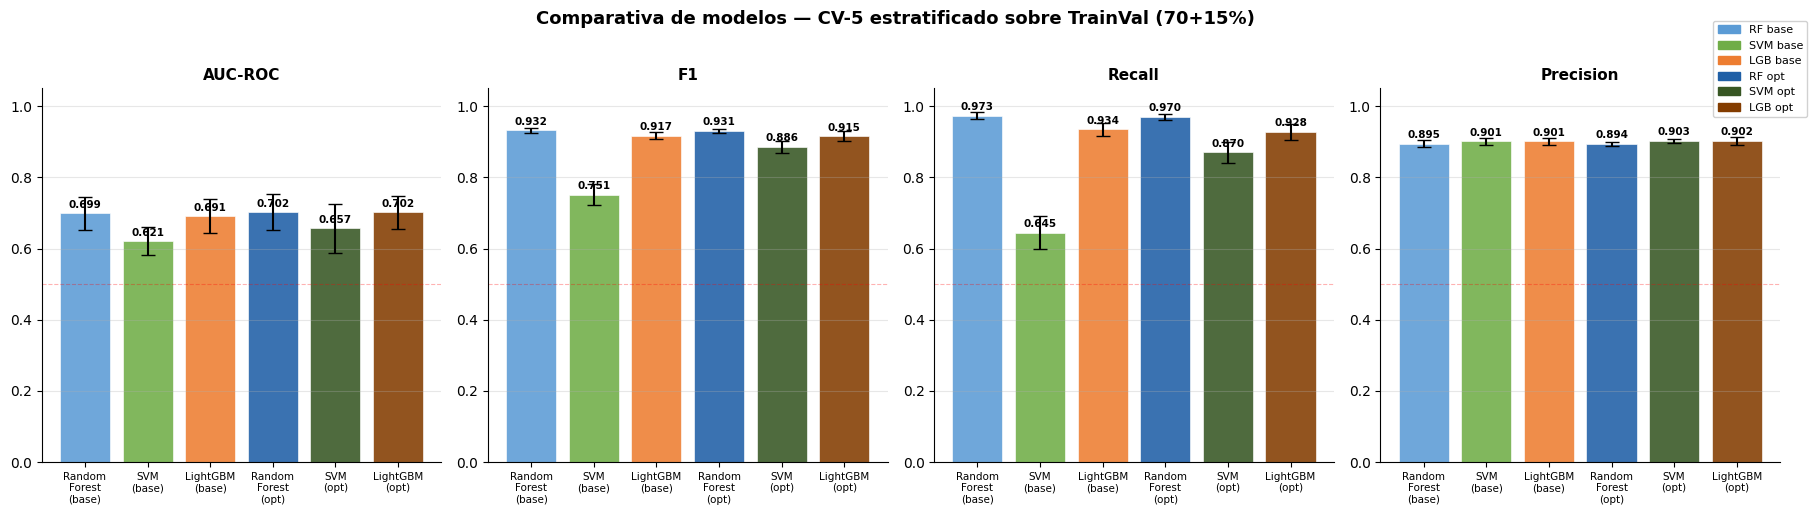

Gráfico guardado en models/model_comparison.png


In [12]:
# Preparar datos para gráficos
metrics_to_plot = ['test_roc_auc', 'test_f1', 'test_recall', 'test_precision']
metric_labels   = ['AUC-ROC', 'F1', 'Recall', 'Precision']
model_names     = list(all_results.keys())

# Paleta de colores: base=semitransparente, optimizado=sólido
colors_base = ['#5b9bd5', '#70ad47', '#ed7d31']
colors_opt  = ['#1f5fa6', '#375623', '#833c00']
model_colors = colors_base + colors_opt

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Comparativa de modelos — CV-5 estratificado sobre TrainVal (70+15%)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    means = [all_results[m][metric].mean() for m in model_names]
    stds  = [all_results[m][metric].std()  for m in model_names]

    bars = ax.bar(range(len(model_names)), means, yerr=stds,
                  color=model_colors, capsize=5, alpha=0.88,
                  edgecolor='white', linewidth=0.5)

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=7.5)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.3, linewidth=0.8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# Leyenda
legend_patches = [
    mpatches.Patch(color=colors_base[0], label='RF base'),
    mpatches.Patch(color=colors_base[1], label='SVM base'),
    mpatches.Patch(color=colors_base[2], label='LGB base'),
    mpatches.Patch(color=colors_opt[0], label='RF opt'),
    mpatches.Patch(color=colors_opt[1], label='SVM opt'),
    mpatches.Patch(color=colors_opt[2], label='LGB opt'),
]
fig.legend(handles=legend_patches, loc='upper right',
           bbox_to_anchor=(1.01, 1.01), fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado en models/model_comparison.png")

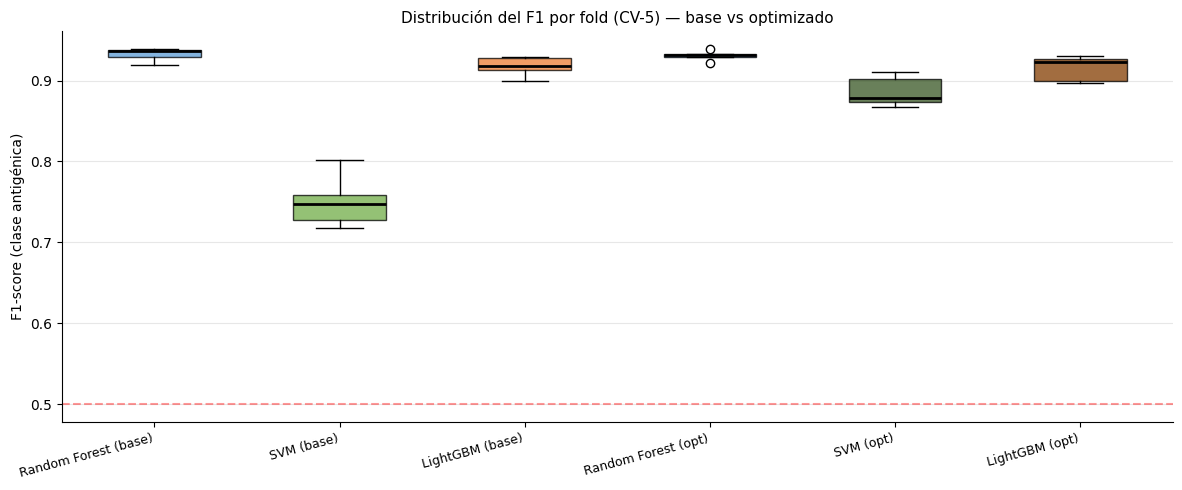

In [13]:
# ── Boxplots de distribución de F1 por fold ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

f1_data = [all_results[m]['test_f1'] for m in model_names]
bp = ax.boxplot(f1_data, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], model_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(model_names)+1))
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('F1-score (clase antigénica)', fontsize=10)
ax.set_title('Distribución del F1 por fold (CV-5) — base vs optimizado', fontsize=11)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'f1_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluación final sobre el Test Set (intocable)

> El test set **nunca** se usó para entrenamiento ni selección de modelo.  
> Esta es la evaluación **honesta** del rendimiento real.

In [14]:
# Seleccionar el mejor modelo según F1 en CV
best_name = max(opt_results, key=lambda m: opt_results[m]['test_f1'].mean())
best_model_cv_f1 = opt_results[best_name]['test_f1'].mean()
print(f"Mejor modelo (CV-F1={best_model_cv_f1:.4f}): {best_name}")

# Re-entrenar sobre TODO trainval con los mejores hiperparámetros
best_model = optimized_models[best_name]
best_model.fit(X_trainval, y_trainval)

# ── Evaluación sobre test ─────────────────────────────────────────────────────
y_test_pred  = best_model.predict(X_test)
y_test_prob  = best_model.predict_proba(X_test)[:, 1]

test_auc  = roc_auc_score(y_test, y_test_prob)
test_f1   = f1_score(y_test, y_test_pred)
test_rec  = recall_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)

print("\n" + "="*50)
print(f"EVALUACIÓN FINAL — TEST SET (15%)")
print("="*50)
print(f"  Modelo:    {best_name}")
print(f"  AUC-ROC:   {test_auc:.4f}")
print(f"  F1:        {test_f1:.4f}")
print(f"  Recall:    {test_rec:.4f}")
print(f"  Precision: {test_prec:.4f}")
print("="*50)
print()
print(classification_report(y_test, y_test_pred,
      target_names=['No antigénica (0)', 'Antigénica (1)']))

Mejor modelo (CV-F1=0.9307): Random Forest (opt)

EVALUACIÓN FINAL — TEST SET (15%)
  Modelo:    Random Forest (opt)
  AUC-ROC:   0.7001
  F1:        0.9382
  Recall:    0.9653
  Precision: 0.9126

                   precision    recall  f1-score   support

No antigénica (0)       0.57      0.33      0.42        24
   Antigénica (1)       0.91      0.97      0.94       173

         accuracy                           0.89       197
        macro avg       0.74      0.65      0.68       197
     weighted avg       0.87      0.89      0.88       197



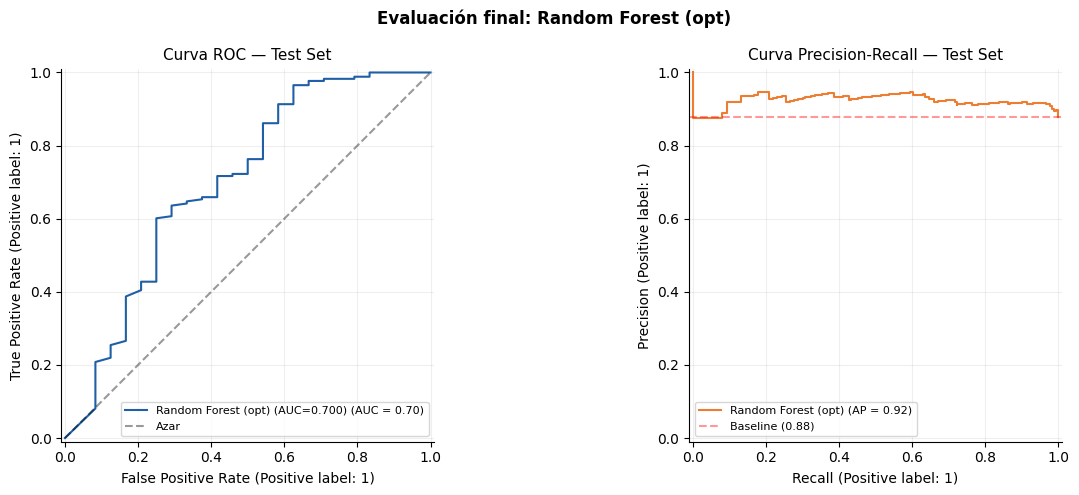

In [15]:
# ── Curvas ROC + Precision-Recall del mejor modelo ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
RocCurveDisplay.from_predictions(
    y_test, y_test_prob,
    name=f"{best_name} (AUC={test_auc:.3f})",
    ax=axes[0], color='#1f5fa6'
)
axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Azar')
axes[0].set_title('Curva ROC — Test Set', fontsize=11)
axes[0].legend(fontsize=8)

# Precision-Recall
PrecisionRecallDisplay.from_predictions(
    y_test, y_test_prob,
    name=f"{best_name}",
    ax=axes[1], color='#ed7d31'
)
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='red', linestyle='--', alpha=0.4,
                label=f'Baseline ({baseline_pr:.2f})')
axes[1].set_title('Curva Precision-Recall — Test Set', fontsize=11)
axes[1].legend(fontsize=8)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.2)

plt.suptitle(f'Evaluación final: {best_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'final_curves.png', dpi=150, bbox_inches='tight')
plt.show()

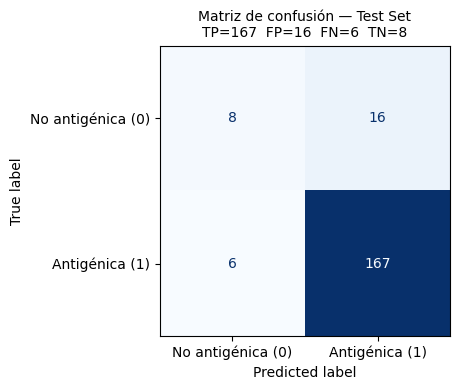


⚠️  Falsos negativos (antigénicas perdidas): 6
   Falsos positivos (candidatos falsos):    16


In [16]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['No antigénica (0)', 'Antigénica (1)'],
    ax=ax, colorbar=False, cmap='Blues'
)
tn = ((y_test==0) & (y_test_pred==0)).sum()
fp = ((y_test==0) & (y_test_pred==1)).sum()
fn = ((y_test==1) & (y_test_pred==0)).sum()
tp = ((y_test==1) & (y_test_pred==1)).sum()
ax.set_title(f'Matriz de confusión — Test Set\n'
             f'TP={tp}  FP={fp}  FN={fn}  TN={tn}', fontsize=10)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n⚠️  Falsos negativos (antigénicas perdidas): {fn}")
print(f"   Falsos positivos (candidatos falsos):    {fp}")

## 7. Importancia de features del mejor modelo

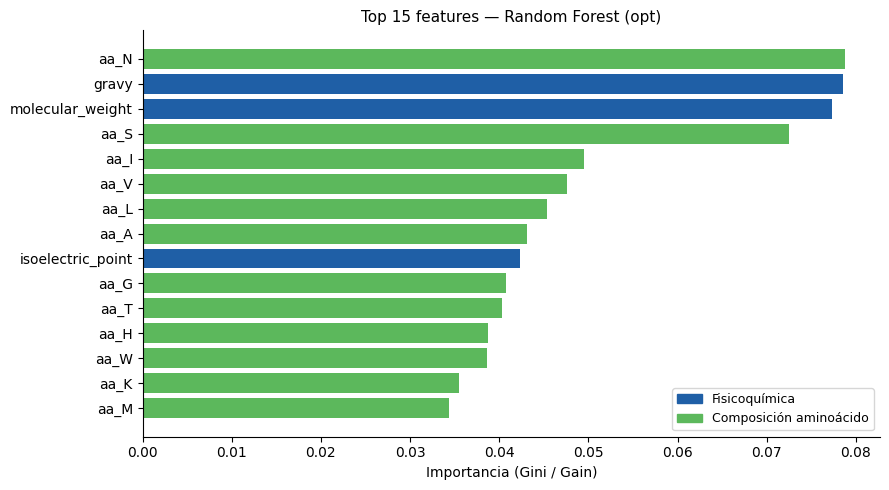

Features fisicoquímicas: 0.2149 (21.5%)
Composición aminoácidos: 0.7851 (78.5%)


In [17]:
# Extraer importancias según el tipo de modelo
def get_feature_importances(model, feature_names):
    """Extrae importancias de RF o LightGBM, o coeficientes de SVM."""
    # Si es Pipeline, extraer el clasificador
    clf = model.named_steps['clf'] if hasattr(model, 'named_steps') else model

    if hasattr(clf, 'feature_importances_'):  # RF, LightGBM
        imp = clf.feature_importances_
        label = 'Importancia (Gini / Gain)'
    elif hasattr(clf, 'coef_'):               # SVM lineal
        imp = np.abs(clf.coef_[0])
        label = '|Coeficiente|'
    else:
        print(f"El modelo {type(clf).__name__} con kernel no lineal no tiene importancias directas.")
        return None, None

    s = pd.Series(imp, index=feature_names).sort_values(ascending=False)
    return s, label

importances, imp_label = get_feature_importances(best_model, FEATURE_COLS)

if importances is not None:
    top15 = importances.head(15)
    colors = ['#1f5fa6' if not f.startswith('aa_') else '#5cb85c' for f in top15.index]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
    ax.set_xlabel(imp_label)
    ax.set_title(f'Top 15 features — {best_name}', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    legend_patches = [
        mpatches.Patch(color='#1f5fa6', label='Fisicoquímica'),
        mpatches.Patch(color='#5cb85c', label='Composición aminoácido')
    ]
    ax.legend(handles=legend_patches, fontsize=9)
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'feature_importance_best.png', dpi=150, bbox_inches='tight')
    plt.show()

    fisico_imp = importances[['length', 'molecular_weight', 'isoelectric_point', 'gravy']].sum()
    aa_imp     = importances[[f for f in FEATURE_COLS if f.startswith('aa_')]].sum()
    total      = fisico_imp + aa_imp
    print(f"Features fisicoquímicas: {fisico_imp:.4f} ({fisico_imp/total:.1%})")
    print(f"Composición aminoácidos: {aa_imp:.4f} ({aa_imp/total:.1%})")

## 8. Tabla de mejores hiperparámetros encontrados

In [18]:
print("MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("="*60)

searches = {
    'Random Forest':  rf_search,
    'SVM':            svm_search,
    'LightGBM':       lgb_search,
}

for name, search in searches.items():
    cv_f1 = search.best_score_
    print(f"\n{name} — CV F1: {cv_f1:.4f}")
    for k, v in search.best_params_.items():
        print(f"  {k:<25} {v}")

MEJORES HIPERPARÁMETROS ENCONTRADOS

Random Forest — CV F1: 0.9307
  class_weight              balanced_subsample
  max_depth                 30
  max_features              0.5
  min_samples_leaf          1
  min_samples_split         2
  n_estimators              502

SVM — CV F1: 0.8860
  clf__C                    68.33635188254583
  clf__class_weight         balanced
  clf__gamma                0.9517143064099162
  clf__kernel               rbf

LightGBM — CV F1: 0.9150
  class_weight              balanced
  colsample_bytree          0.5806106436270022
  learning_rate             0.2889092957027719
  max_depth                 11
  min_child_samples         15
  n_estimators              127
  num_leaves                127
  reg_alpha                 0.18657005888603584
  reg_lambda                0.8925589984899778
  subsample                 0.7696711209578253


## 9. Guardar el mejor modelo

In [19]:
MODEL_PATH = MODELS_DIR / 'best_model.pkl'

model_bundle = {
    'model':           best_model,
    'model_name':      best_name,
    'feature_cols':    FEATURE_COLS,
    'amino_acids':     AMINO_ACIDS,
    'label_map':       {0: 'No antigénica', 1: 'Antigénica'},
    'n_train':         len(X_trainval),
    'split':           {'train': 0.70, 'val': 0.15, 'test': 0.15},
    'cv_f1':           float(opt_results[best_name]['test_f1'].mean()),
    'cv_auc':          float(opt_results[best_name]['test_roc_auc'].mean()),
    'test_f1':         float(test_f1),
    'test_auc':        float(test_auc),
    'test_recall':     float(test_rec),
    'test_precision':  float(test_prec),
    'best_params':     best_model.named_steps['clf'].get_params()
                       if hasattr(best_model, 'named_steps')
                       else best_model.get_params(),
}

joblib.dump(model_bundle, MODEL_PATH)
print(f"Modelo guardado en: {MODEL_PATH}")
print(f"\n{'='*50}")
print(f"RESUMEN FINAL")
print(f"{'='*50}")
print(f"  Mejor modelo:  {best_name}")
print(f"  Split:         70% train / 15% val / 15% test")
print(f"  CV F1  (val):  {model_bundle['cv_f1']:.4f}")
print(f"  Test F1:       {model_bundle['test_f1']:.4f}")
print(f"  Test AUC-ROC:  {model_bundle['test_auc']:.4f}")
print(f"  Test Recall:   {model_bundle['test_recall']:.4f}")
print(f"  Test Precision:{model_bundle['test_precision']:.4f}")
print(f"{'='*50}")

Modelo guardado en: ..\models\best_model.pkl

RESUMEN FINAL
  Mejor modelo:  Random Forest (opt)
  Split:         70% train / 15% val / 15% test
  CV F1  (val):  0.9307
  Test F1:       0.9382
  Test AUC-ROC:  0.7001
  Test Recall:   0.9653
  Test Precision:0.9126
